In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("customer_data.csv")

In [3]:
print("Data Sample:\n", df.head())

Data Sample:
   Customer_ID  Age  Annual_Income (k)  Spending_Score  Visit_Frequency
0        C001   34                127              68                9
1        C002   34                 58              20               17
2        C003   31                 34              96               12
3        C004   26                139              68               25
4        C005   57                 23              91               14


In [13]:
features = ["Age", "Annual_Income (k)", "Spending_Score", "Visit_Frequency"]
X = df[features]

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [15]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Wi

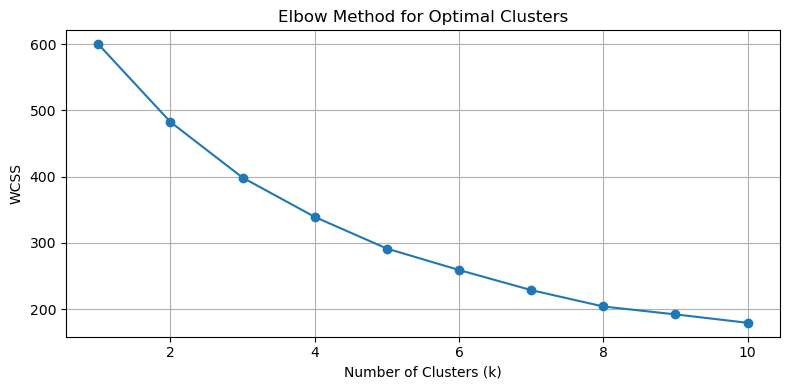

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
k = 4
kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


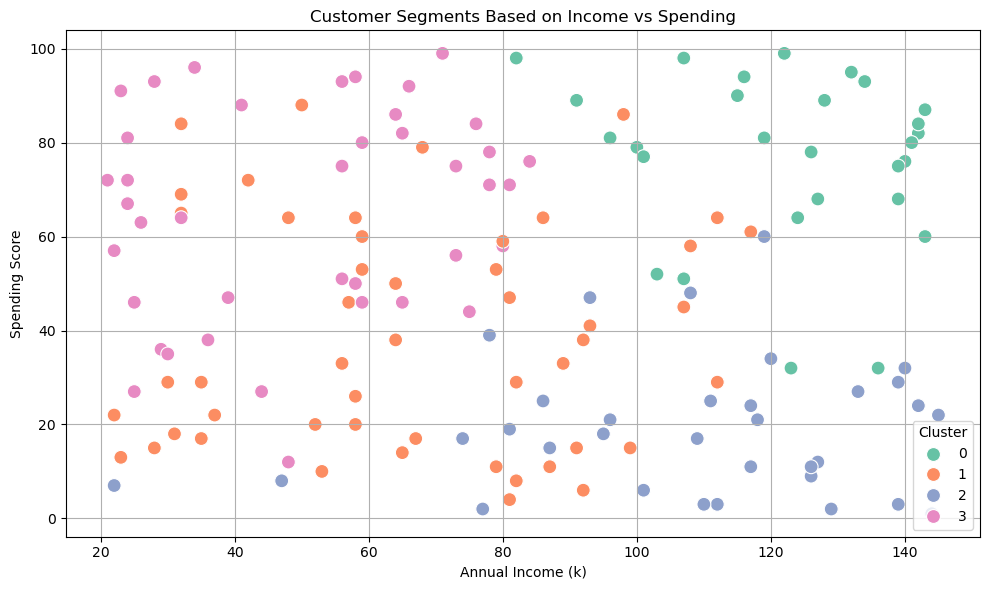

In [18]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Annual_Income (k)", y="Spending_Score", hue="Cluster", palette="Set2", s=100)
plt.title("Customer Segments Based on Income vs Spending")
plt.xlabel("Annual Income (k)")
plt.ylabel("Spending Score")
plt.legend(title="Cluster")
plt.grid(True)
plt.tight_layout()
plt.show()

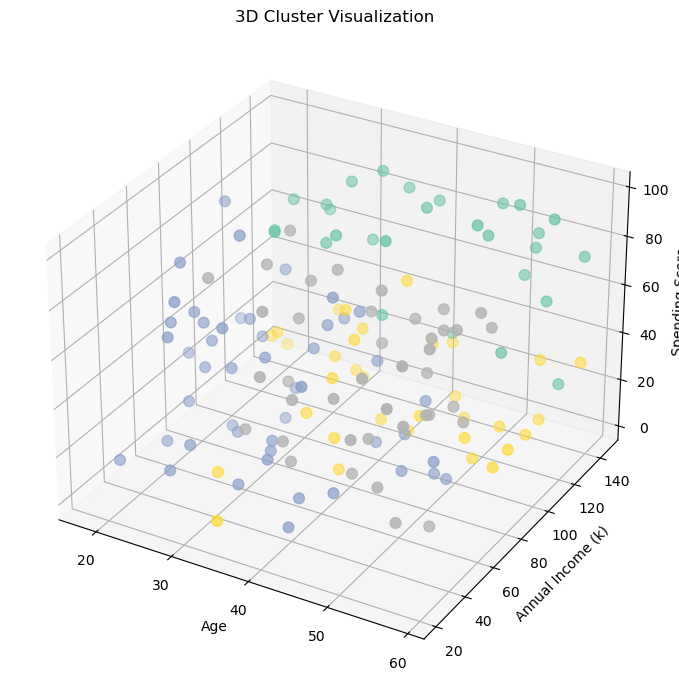

In [22]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df["Age"],
    df["Annual_Income (k)"],
    df["Spending_Score"],
    c=df["Cluster"],
    cmap="Set2",
    s=60
)

ax.set_xlabel("Age")
ax.set_ylabel("Annual Income (k)")
ax.set_zlabel("Spending Score")
ax.set_title("3D Cluster Visualization")
plt.tight_layout()
plt.show()

In [19]:
print("Customer Segment Descriptions:\n")
for i in range(k):
    segment = df[df['Cluster'] == i]
    print(f"Segment {i}:")
    print(f"- Count: {len(segment)}")
    print(f"- Avg Age: {segment['Age'].mean():.1f}")
    print(f"- Avg Income: {segment['Annual_Income (k)'].mean():.1f}")
    print(f"- Avg Spending Score: {segment['Spending_Score'].mean():.1f}")
    print(f"- Avg Visit Frequency: {segment['Visit_Frequency'].mean():.1f}")
    print("Suggested Marketing Strategy:", end=" ")

Customer Segment Descriptions:

Segment 0:
- Count: 28
- Avg Age: 42.6
- Avg Income: 122.1
- Avg Spending Score: 76.9
- Avg Visit Frequency: 14.2
Suggested Marketing Strategy: Segment 1:
- Count: 49
- Avg Age: 32.2
- Avg Income: 66.6
- Avg Spending Score: 39.1
- Avg Visit Frequency: 8.3
Suggested Marketing Strategy: Segment 2:
- Count: 33
- Avg Age: 40.7
- Avg Income: 108.1
- Avg Spending Score: 19.5
- Avg Visit Frequency: 21.2
Suggested Marketing Strategy: Segment 3:
- Count: 40
- Avg Age: 47.8
- Avg Income: 50.1
- Avg Spending Score: 65.5
- Avg Visit Frequency: 18.1
Suggested Marketing Strategy: 

In [20]:
    if segment['Spending_Score'].mean() > 70:
        print("Promote premium offers & loyalty programs.\n")
    elif segment['Annual_Income (k)'].mean() > 100:
        print("Market high-end products with exclusivity.\n")
    elif segment['Visit_Frequency'].mean() > 20:
        print("Offer discounts for frequent buyers.\n")
    else:
        print("Use budget deals and limited-time promotions.\n")

Use budget deals and limited-time promotions.

